## DATA ANALYSIS ON ONLINE SHOPPING DATA 

## Importing required library

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

###  Loading the dataset

In [15]:
df = pd.read_csv(r'C:\Users\dell\Downloads\new_retail_data.csv')
df.head()

,Transaction_ID,Customer_ID,Name,Email,Phone,Address,City,State,Zipcode,Country,...,Total_Amount,Product_Category,Product_Brand,Product_Type,Feedback,Shipping_Method,Payment_Method,Order_Status,Ratings,products
0,8691788.0,37249.0,Michelle Harrington,Ebony39@gmail.com,1.414787e+09,3959 Amanda Burgs,Dortmund,Berlin,77985.0,Germany,...,324.086270,Clothing,Nike,Shorts,Excellent,Same-Day,Debit Card,Shipped,5.0,Cycling shorts
1,2174773.0,69749.0,Kelsey Hill,Mark36@gmail.com,6.852900e+09,82072 Dawn Centers,Nottingham,England,99071.0,UK,...,806.707815,Electronics,Samsung,Tablet,Excellent,Standard,Credit Card,Processing,4.0,Lenovo Tab
2,6679610.0,30192.0,Scott Jensen,Shane85@gmail.com,8.362160e+09,4133 Young Canyon,Geelong,New South Wales,75929.0,Australia,...,1063.432799,Books,Penguin Books,Children's,Average,Same-Day,Credit Card,Processing,2.0,Sports equipment
3,7232460.0,62101.0,Joseph Miller,Mary34@gmail.com,2.776752e+09,8148 Thomas Creek Suite 100,Edmonton,Ontario,88420.0,Canada,...,2466.854021,Home Decor,Home Depot,Tools,Excellent,Standard,PayPal,Processing,4.0,Utility knife
4,4983775.0,27901.0,Debra Coleman,Charles30@gmail.com,9.098268e+09,5813 Lori Ports Suite 269,Bristol,England,48704.0,UK,...,248.553049,Grocery,Nestle,Chocolate,Bad,Standard,Cash,Shipped,1.0,Chocolate cookies


### Market Trend Analysis 
We analyze current trends in the home decor sector by identifying the most frequently purchased product categories.<br> The data from the Product_Category column helps determine which products are in high demand. <br>We visualize this using bar charts and word clouds to highlight the most popular categories.


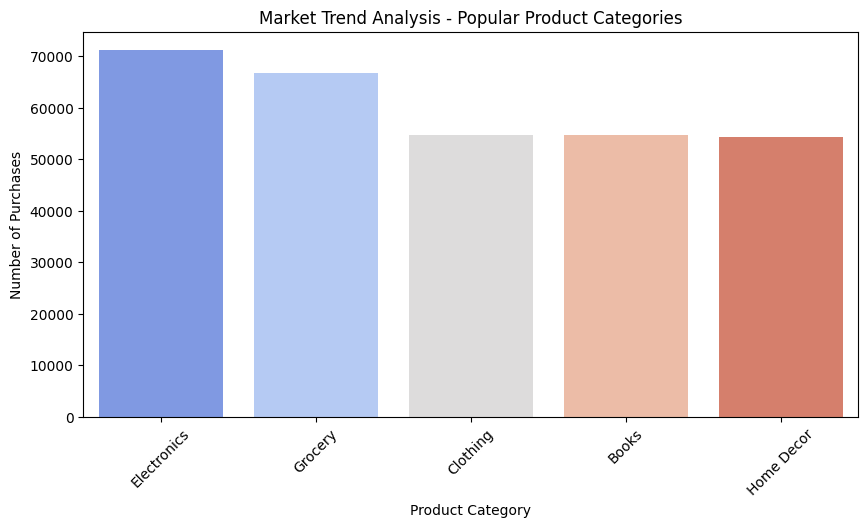

In [23]:
def analyze_trends():
# Count the number of purchases per product category
    trend_counts = df['Product_Category'].value_counts()
# Visualizing trends using a bar chart
    plt.figure(figsize=(10, 5))
    sns.barplot(x=trend_counts.index, y=trend_counts.values, hue=trend_counts.index, palette='coolwarm', legend=False)

    plt.xlabel('Product Category')
    plt.ylabel('Number of Purchases')
    plt.title('Market Trend Analysis - Popular Product Categories')
    plt.xticks(rotation=45)
    plt.show()
    

analyze_trends()   

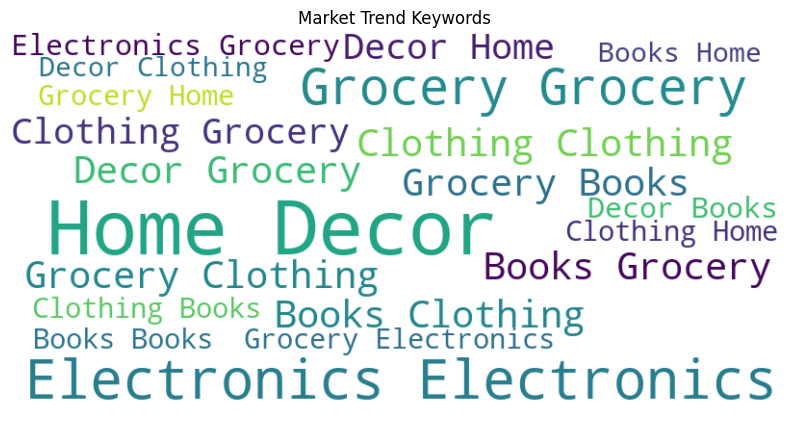

In [26]:
# Generating a word cloud for market trends
text = ' '.join(df['Product_Category'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Market Trend Keywords")
plt.show()

### Competitor Analysis
We analyze key competitors in the market based on their revenue. <br> The dataset’s Product_Brand and Total_Amount columns help us determine the top-performing brands by summing their total sales revenue.

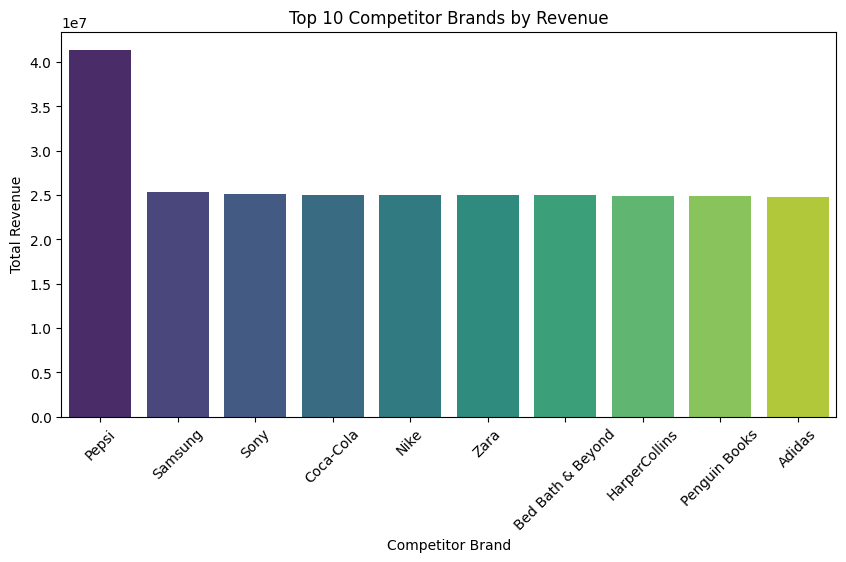

In [32]:
# Calculate revenue per brand
def analyze_competitors():
    brand_revenue = df.groupby('Product_Brand')['Total_Amount'].sum().sort_values(ascending=False)
# Creating Visuals    
    plt.figure(figsize=(10, 5))
    sns.barplot(x=brand_revenue.index[:10], y=brand_revenue.values[:10], hue=brand_revenue.index[:10], palette='viridis', legend=False)

    plt.xlabel('Competitor Brand')
    plt.ylabel('Total Revenue')
    plt.title('Top 10 Competitor Brands by Revenue')
    plt.xticks(rotation=45)
    plt.show()
analyze_competitors()    

## Customer Behavior Analysis
This step aims to understand customer preferences and purchase behavior.<br> 
We analyze Customer feedback to see common reasons for purchasing.<br>
Preferred payment methods to help businesses improve their checkout experience.

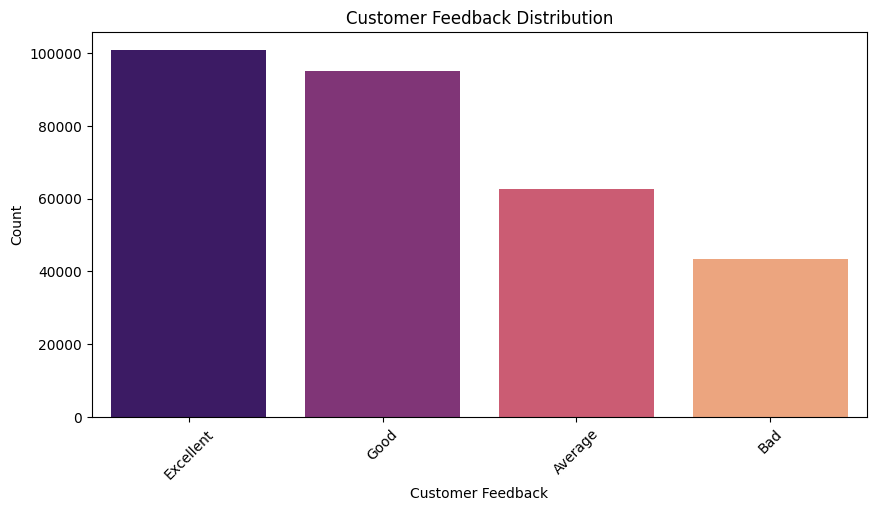

In [33]:
# Analyzing customer feedback distribution
def analyze_customer_behavior():
    reasons_count = df['Feedback'].value_counts()
    
    plt.figure(figsize=(10, 5))
    sns.barplot(x=reasons_count.index, y=reasons_count.values, hue=reasons_count.index, palette='magma', legend=False)

    plt.xlabel('Customer Feedback')
    plt.ylabel('Count')
    plt.title('Customer Feedback Distribution')
    plt.xticks(rotation=45)
    plt.show()
analyze_customer_behavior()    

### Identifying preferred payment methods
Here we analyzes that in what way our customer like to pay their bills (online  cash etc) 

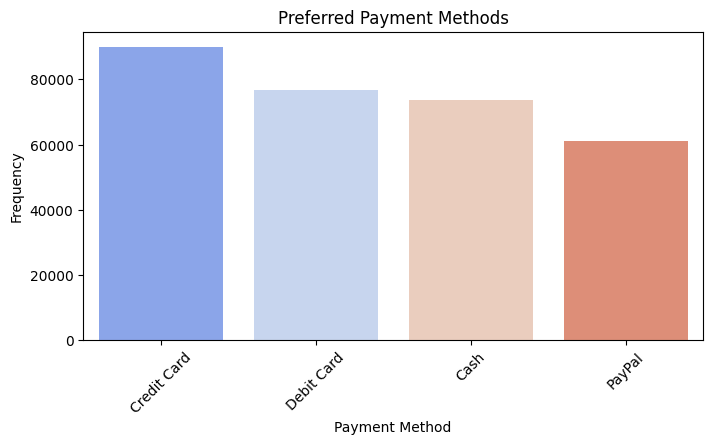

In [35]:
payment_counts = df['Payment_Method'].value_counts()
plt.figure(figsize=(8, 4))
sns.barplot(x=payment_counts.index, y=payment_counts.values, hue=payment_counts.index, palette='coolwarm', legend=False)
plt.xlabel('Payment Method')
plt.ylabel('Frequency')
plt.title('Preferred Payment Methods')
plt.xticks(rotation=45)
plt.show()

## Market Share 
Here we analyze that how many percentage of market has been captured by our company or our competitors

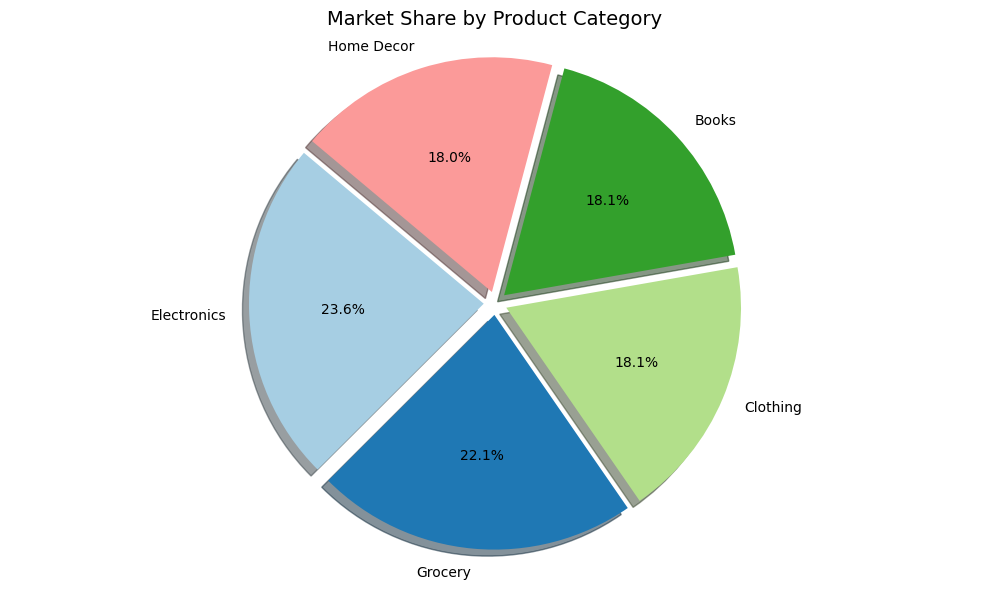

In [36]:
category_counts = df["Product_Category"].value_counts()


# Percentage shared by market by each sector 
plt.figure(figsize=(10, 6))  # Adjust figure size
colors = plt.cm.Paired.colors  # Use a predefined colormap for distinct colors
explode = [0.05] * len(category_counts)  # Slightly separate slices for clarity

plt.pie(category_counts, labels=category_counts.index, autopct='%1.1f%%', 
        startangle=140, colors=colors, explode=explode, shadow=True)

plt.title("Market Share by Product Category", fontsize=14)
plt.axis('equal')  # Keeps pie chart circular
plt.tight_layout()  # Adjusts layout to prevent overlap

# Show chart
plt.show()